
<img src="https://www.mmu.edu.my/fci/wp-content/uploads/2021/01/FCI_wNEW_MMU_LOGO.png" style="height: 80px;" align=left>


CDS6214 Data Science Fundamentals

Trimester 1, 2024/2025

Project (40%)

NAME : LAM ZI FOONG  
ID : 1221303175

NAME : TEOH KAI LOON<br>
ID : 1211101582

NAME : CHAI DI SHENG  
ID : 1211101961

NAME :WONG KAH CHUN<BR>
ID :1221304973




In [ ]:
from google.colab import drive
drive.mount(('/content/drive'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dp=('/content/drive/MyDrive/G17 Datasc/')

# Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
  dp
except NameError:
  dp = ''


df = pd.read_csv(dp + 'Toronto2020.csv')

# Create a DataFrame with the necessary info
info_dict = {
    'Column': df.columns,
    'Null Count': df.isnull().sum().values,
    'Dtype': df.dtypes.values
}

info_df = pd.DataFrame(info_dict)
info_df.index.name = '#'

# Display the DataFrame with borders
info_df.style.set_table_styles([
])

,Column,Null Count,Dtype
#,,,
0,Longitude (x),0,float64
1,Latitude (y),0,float64
2,Station Name,0,object
3,Climate ID,0,int64
4,Date/Time,0,object
5,Year,0,int64
6,Month,0,int64
7,Day,0,int64
8,Time,0,object


###Data Cleaning

Drop the column which having almost all missing values.

In [ ]:
df_clean = df.copy()
#drop columns with all missing value
df_clean.dropna(axis=1, how='all', inplace=True)

#drop columns with high missing value
df_clean.drop(columns=['Wind Dir Flag','Temp Flag','Dew Point Temp Flag', 'Rel Hum Flag', 'Wind Spd Flag', 'Visibility Flag', 'Stn Press Flag', 'Hmdx', 'Wind Chill', 'Weather'], inplace=True)

display(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Longitude (x)        8784 non-null   float64
 1   Latitude (y)         8784 non-null   float64
 2   Station Name         8784 non-null   object 
 3   Climate ID           8784 non-null   int64  
 4   Date/Time            8784 non-null   object 
 5   Year                 8784 non-null   int64  
 6   Month                8784 non-null   int64  
 7   Day                  8784 non-null   int64  
 8   Time                 8784 non-null   object 
 9   Temp (°C)            8771 non-null   float64
 10  Dew Point Temp (°C)  8772 non-null   float64
 11  Rel Hum (%)          8777 non-null   float64
 12  Wind Dir (10s deg)   8358 non-null   float64
 13  Wind Spd (km/h)      8770 non-null   float64
 14  Visibility (km)      8768 non-null   float64
 15  Stn Press (kPa)      8772 non-null   f

None

Fill in the numeric missing value.

In [ ]:
cols_to_fill = ['Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'Wind Dir (10s deg)']

# Calculate monthly means for each column
monthly_means = df_clean.groupby('Month')[cols_to_fill].transform('mean')

# Fill missing values in each column with corresponding monthly means
for col in cols_to_fill:
  df_clean[col] = df_clean[col].fillna(monthly_means[col])

# Display information about the DataFrame
print(df_clean.isnull().sum())

Longitude (x)          0
Latitude (y)           0
Station Name           0
Climate ID             0
Date/Time              0
Year                   0
Month                  0
Day                    0
Time                   0
Temp (°C)              0
Dew Point Temp (°C)    0
Rel Hum (%)            0
Wind Dir (10s deg)     0
Wind Spd (km/h)        0
Visibility (km)        0
Stn Press (kPa)        0
dtype: int64


Drop unused dataframes.

In [ ]:
#having same value or not using
df_clean.drop(columns=['Longitude (x)', 'Latitude (y)', 'Station Name','Climate ID','Date/Time','Year'], inplace=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Month                8784 non-null   int64  
 1   Day                  8784 non-null   int64  
 2   Time                 8784 non-null   object 
 3   Temp (°C)            8784 non-null   float64
 4   Dew Point Temp (°C)  8784 non-null   float64
 5   Rel Hum (%)          8784 non-null   float64
 6   Wind Dir (10s deg)   8784 non-null   float64
 7   Wind Spd (km/h)      8784 non-null   float64
 8   Visibility (km)      8784 non-null   float64
 9   Stn Press (kPa)      8784 non-null   float64
dtypes: float64(7), int64(2), object(1)
memory usage: 686.4+ KB


Checking duplicated data

In [ ]:
df_clean.duplicated().sum()

0

##Data Transformation

Converts categorical data

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Encode the 'Time' column in df_clean using LabelEncoder, transforming its values into numeric labels
encoder = LabelEncoder()
df_clean['Time'] = encoder.fit_transform(df_clean['Time'])

##Data Spliting

In [ ]:
from sklearn.model_selection import train_test_split
# Drop the 'Temp (°C)' column from df_clean and store the resulting dataframe in x
x= df_clean.drop('Temp (°C)', axis=1)
X_train, X_test, y_train, y_test = train_test_split(x, df_clean['Temp (°C)'], test_size=0.2, random_state=42)#split data to test and train data

# Data Exploration





Describe the data

In [ ]:
#get the first 10 row
df_clean.head(10)

,Month,Day,Time,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Dir (10s deg),Wind Spd (km/h),Visibility (km),Stn Press (kPa)
0,1,1,0,0.2,-3.7,75.0,25.0,35.0,16.1,99.30
1,1,1,11,0.1,-4.0,74.0,25.0,34.0,16.1,99.33
2,1,1,16,0.0,-3.9,75.0,25.0,34.0,16.1,99.36
3,1,1,17,-0.2,-4.3,74.0,25.0,32.0,16.1,99.40
4,1,1,18,-0.2,-4.1,75.0,25.0,28.0,16.1,99.45
5,1,1,19,-0.2,-4.3,74.0,25.0,32.0,16.1,99.44
6,1,1,20,-0.3,-4.0,76.0,25.0,32.0,16.1,99.49
7,1,1,21,-0.3,-4.3,75.0,25.0,30.0,16.1,99.53
8,1,1,22,-0.3,-4.5,73.0,25.0,28.0,16.1,99.61
9,1,1,23,-0.3,-3.8,77.0,25.0,28.0,16.1,99.67


Display data types

In [ ]:
#see datatypes
df_clean.dtypes

Month                    int64
Day                      int64
Time                     int64
Temp (°C)              float64
Dew Point Temp (°C)    float64
Rel Hum (%)            float64
Wind Dir (10s deg)     float64
Wind Spd (km/h)        float64
Visibility (km)        float64
Stn Press (kPa)        float64
dtype: object

Display the shape of data

In [ ]:
# Display the shape of the df_clean DataFrame
df_clean.shape

(8784, 10)

Summary Statistic

In [ ]:
# Display the descriptive statistics of the df_clean
df_clean.describe()

,Month,Day,Time,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Dir (10s deg),Wind Spd (km/h),Visibility (km),Stn Press (kPa)
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,6.513661,15.756831,11.500000,9.794134,4.871908,72.848703,20.090688,16.681863,15.186625,100.680666
std,3.451430,8.812031,6.922581,9.270167,9.478940,14.824293,9.522177,9.566691,2.972239,0.798979
min,1.000000,1.000000,0.000000,-18.400000,-24.100000,16.000000,1.000000,0.000000,0.200000,98.070000
25%,4.000000,8.000000,5.750000,2.400000,-2.500000,63.000000,9.000000,9.000000,16.100000,100.190000
50%,7.000000,16.000000,11.500000,8.200000,3.700000,74.000000,22.000000,15.000000,16.100000,100.650000
75%,10.000000,23.000000,17.250000,18.000000,12.964286,84.000000,28.000000,22.000000,16.100000,101.160000
max,12.000000,31.000000,23.000000,34.100000,24.700000,100.000000,36.000000,68.000000,16.100000,103.710000


**Correlation**

In [ ]:
#see the correlation
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
numeric_df.corr()

,Month,Day,Time,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Dir (10s deg),Wind Spd (km/h),Visibility (km),Stn Press (kPa)
Month,1.000000e+00,6.443300e-03,5.037443e-16,0.292275,0.302932,0.076273,0.027293,-0.106212,0.019321,-0.020156
Day,6.443300e-03,1.000000e+00,2.615762e-16,-0.000812,0.028484,0.080841,-0.135552,0.059064,-0.013236,0.067675
Time,5.037443e-16,2.615762e-16,1.000000e+00,-0.092853,-0.023005,0.191626,0.052710,-0.128090,-0.050326,0.007735
Temp (°C),2.922752e-01,-8.124917e-04,-9.285267e-02,1.000000,0.940806,0.005270,-0.113915,-0.250882,0.113943,-0.247778
Dew Point Temp (°C),3.029323e-01,2.848396e-02,-2.300543e-02,0.940806,1.000000,0.339472,-0.163701,-0.291592,-0.006176,-0.323151
Rel Hum (%),7.627333e-02,8.084118e-02,1.916262e-01,0.005270,0.339472,1.000000,-0.177948,-0.163647,-0.393576,-0.294339
Wind Dir (10s deg),2.729292e-02,-1.355525e-01,5.271048e-02,-0.113915,-0.163701,-0.177948,1.000000,-0.002732,0.115696,-0.129030
Wind Spd (km/h),-1.062117e-01,5.906437e-02,-1.280898e-01,-0.250882,-0.291592,-0.163647,-0.002732,1.000000,0.012986,-0.164707
Visibility (km),1.932072e-02,-1.323626e-02,-5.032563e-02,0.113943,-0.006176,-0.393576,0.115696,0.012986,1.000000,0.211264
Stn Press (kPa),-2.015625e-02,6.767506e-02,7.734502e-03,-0.247778,-0.323151,-0.294339,-0.129030,-0.164707,0.211264,1.000000


heat map

<Axes: >

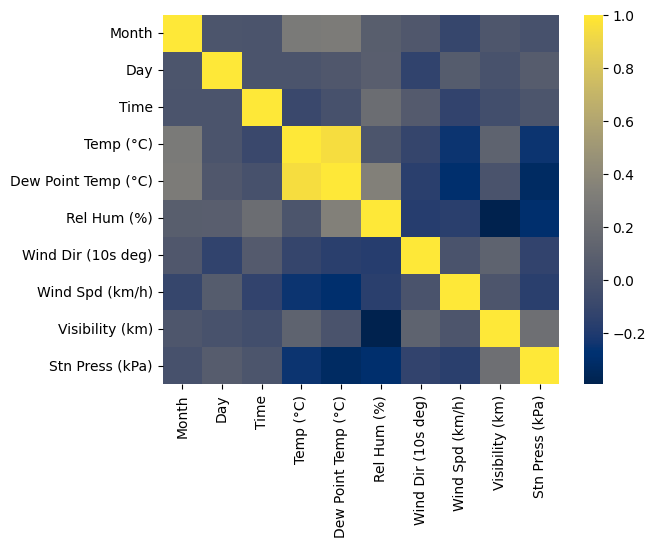

In [ ]:
# Create a heatmap of the correlation matrix
sns.heatmap(df_clean.corr( numeric_only=True), cmap='cividis')

Scatter plot:Humidity vs temperature

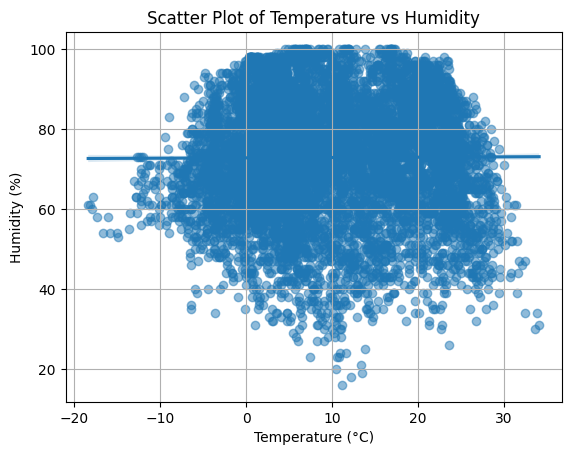

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#plot scatter plot
sns.regplot(x='Temp (°C)', y='Rel Hum (%)', data=df_clean, scatter_kws={'alpha':0.5})
plt.title('Scatter Plot of Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True)


plt.show()

time series for monthly wind speed pattern

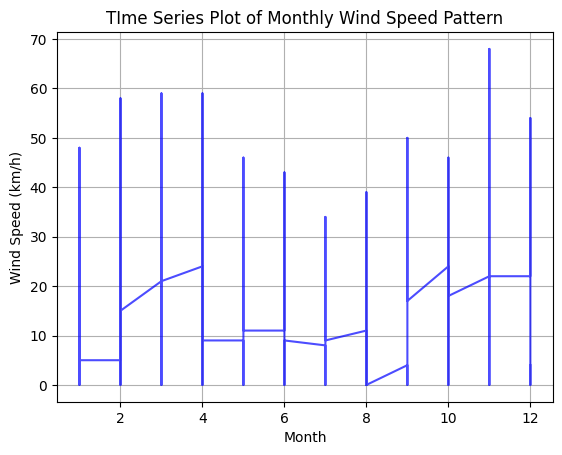

In [ ]:
# Create a time series plot
plt.plot(df_clean['Month'],df_clean['Wind Spd (km/h)'], marker='', linestyle='-', color='b', alpha=0.7)
plt.title('TIme Series Plot of Monthly Wind Speed Pattern')
plt.xlabel('Month')
plt.ylabel('Wind Speed (km/h)')
plt.grid(True)


plt.show()

scatter plot:visibility vs Humidity


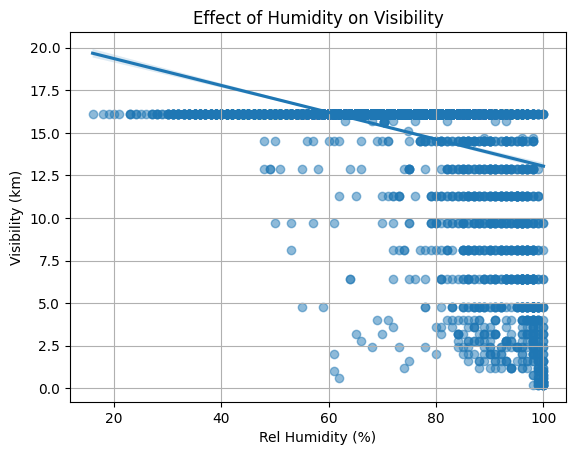

In [ ]:
#plot scatter plot
sns.regplot(x='Rel Hum (%)', y='Visibility (km)', data=df_clean, scatter_kws={'alpha':0.5})
plt.title('Effect of Humidity on Visibility')
plt.xlabel('Rel Humidity (%)')
plt.ylabel('Visibility (km)')
plt.grid(True)

# Show plot
plt.show()

scatter plot:dew point vs temperature

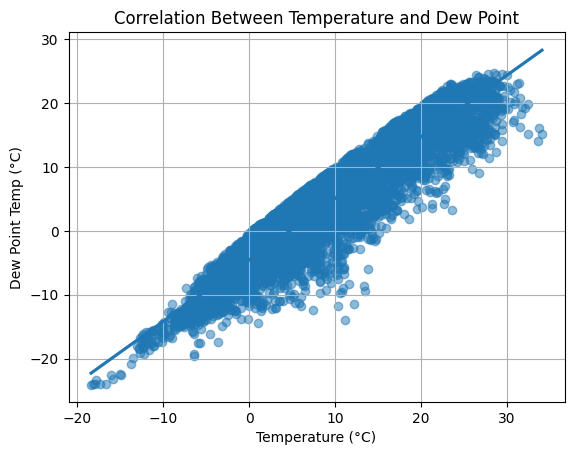

In [ ]:
#plot scatter plot
sns.regplot(x='Temp (°C)', y='Dew Point Temp (°C)', data=df_clean, scatter_kws={'alpha':0.5})
plt.title('Correlation Between Temperature and Dew Point')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dew Point Temp (°C)')
plt.grid(True)


plt.show()

# Data Mining

##K Mean Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler  # For scaling dataset
from sklearn.cluster import KMeans, AgglomerativeClustering, AffinityPropagation

In [ ]:
numeric_df.describe()

,Month,Day,Time,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Dir (10s deg),Wind Spd (km/h),Visibility (km),Stn Press (kPa)
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,6.513661,15.756831,11.500000,9.794134,4.871908,72.848703,20.090688,16.681863,15.186625,100.680666
std,3.451430,8.812031,6.922581,9.270167,9.478940,14.824293,9.522177,9.566691,2.972239,0.798979
min,1.000000,1.000000,0.000000,-18.400000,-24.100000,16.000000,1.000000,0.000000,0.200000,98.070000
25%,4.000000,8.000000,5.750000,2.400000,-2.500000,63.000000,9.000000,9.000000,16.100000,100.190000
50%,7.000000,16.000000,11.500000,8.200000,3.700000,74.000000,22.000000,15.000000,16.100000,100.650000
75%,10.000000,23.000000,17.250000,18.000000,12.964286,84.000000,28.000000,22.000000,16.100000,101.160000
max,12.000000,31.000000,23.000000,34.100000,24.700000,100.000000,36.000000,68.000000,16.100000,103.710000


In [ ]:
# Create an instance of StandardScaler
ss = StandardScaler()
# Fit the StandardScaler to numeric_df and transform it, storing the result in X
X = ss.fit_transform(numeric_df)
print(numeric_df)
print(X)     # observe the values

      Month  Day  Time  Temp (°C)  Dew Point Temp (°C)  Rel Hum (%)  \
0         1    1     0        0.2                 -3.7         75.0   
1         1    1    11        0.1                 -4.0         74.0   
2         1    1    16        0.0                 -3.9         75.0   
3         1    1    17       -0.2                 -4.3         74.0   
4         1    1    18       -0.2                 -4.1         75.0   
...     ...  ...   ...        ...                  ...          ...   
8779     12   31    10        0.1                 -3.3         78.0   
8780     12   31    12        0.0                 -4.0         74.0   
8781     12   31    13        0.4                 -4.5         70.0   
8782     12   31    14       -0.1                 -4.9         70.0   
8783     12   31    15       -1.0                 -4.9         75.0   

      Wind Dir (10s deg)  Wind Spd (km/h)  Visibility (km)  Stn Press (kPa)  
0                   25.0             35.0             16.1           

use StandardScaler() from scikit-learn package to standardize the attribute data

do kmeans


In [ ]:
# Create an instance of the KMeans model with 2 clusters
model = KMeans(2, verbose=0, n_init='auto')
# Fit the KMeans model to the standardized data X
model.fit(X)

KMeans(n_clusters=2, n_init='auto')

In [ ]:
kmeans_labels = pd.DataFrame(model.labels_)   # put into a DataFrame. We will use this shortly...
kmeans_labels

,0
0,0
1,0
2,0
3,0
4,0
...,...
8779,0
8780,0
8781,0
8782,0


In [ ]:
model.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

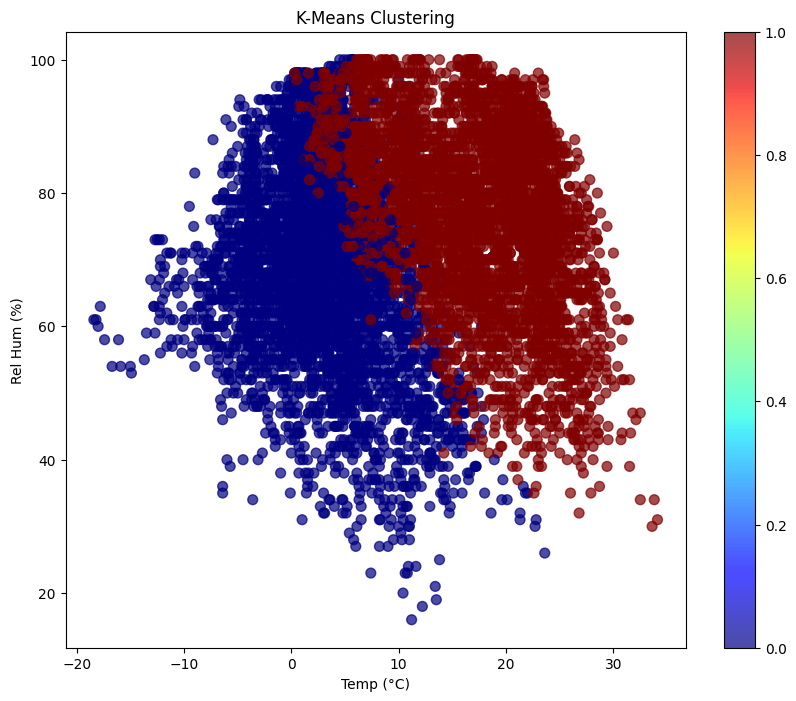

In [ ]:
# Create a scatter plot of v1 vs v2
# c=kmeans_labels colors the points according to the cluster labels
v1 = df_clean['Temp (°C)']
v2 = df_clean['Rel Hum (%)']
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
scatter = ax.scatter(v1, v2, c=kmeans_labels[0],s=50,cmap='jet',alpha=0.7)
ax.set_title('K-Means Clustering')
ax.set_xlabel(v1.name)
ax.set_ylabel(v2.name)
plt.colorbar(scatter)
plt.show()


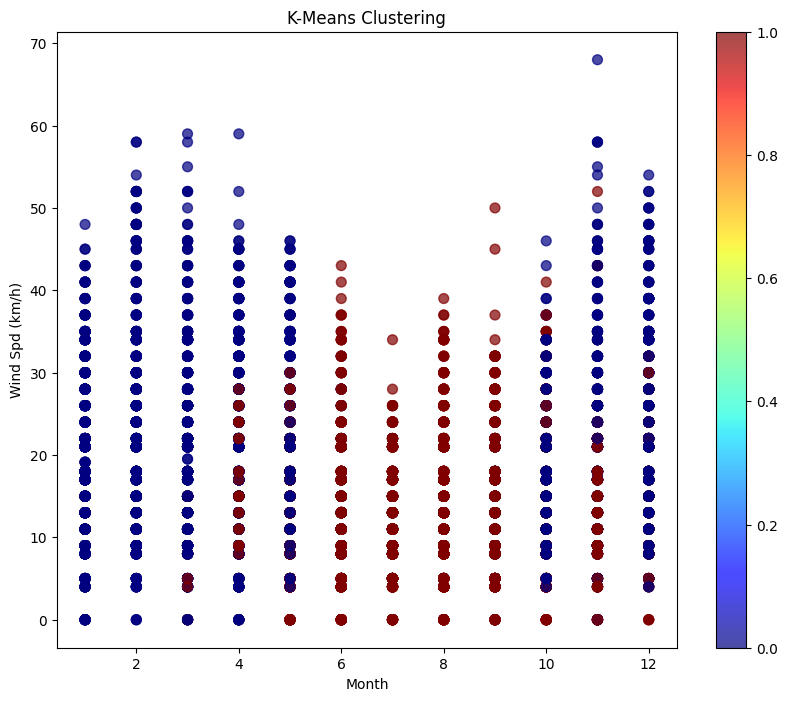

In [ ]:
# Create a scatter plot of v1 vs v2
# c=kmeans_labels colors the points according to the cluster labels
v1 = df_clean['Month']
v2 = df_clean['Wind Spd (km/h)']
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
scatter = ax.scatter(v1, v2, c=kmeans_labels[0],s=50,cmap='jet',alpha=0.7)
ax.set_title('K-Means Clustering')
ax.set_xlabel(v1.name)
ax.set_ylabel(v2.name)
plt.colorbar(scatter)
plt.show()



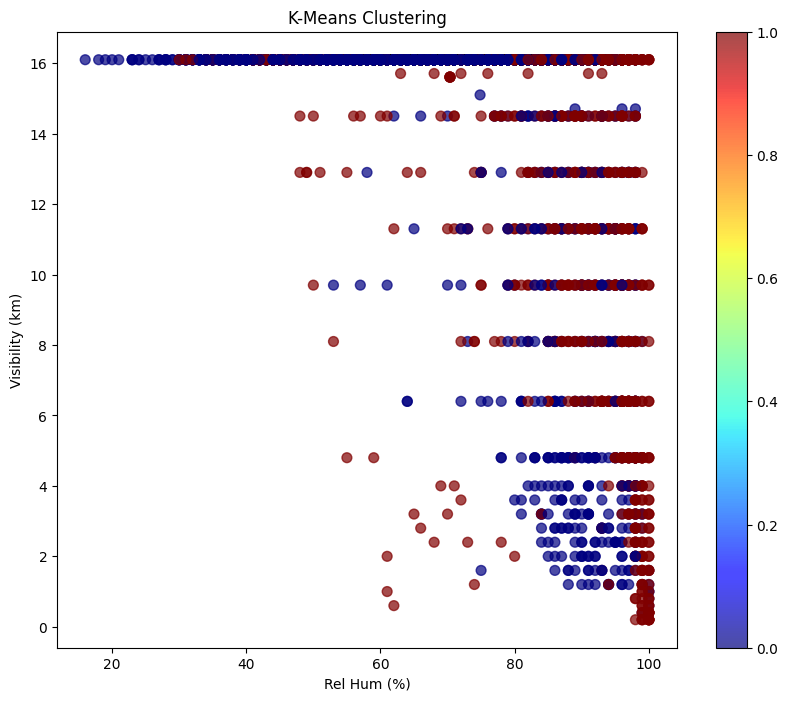

In [ ]:
# Create a scatter plot of v1 vs v2
# c=kmeans_labels colors the points according to the cluster labels
v1 = df_clean['Rel Hum (%)']
v2 = df_clean['Visibility (km)']
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
scatter = ax.scatter(v1, v2, c=kmeans_labels[0],s=50,cmap='jet',alpha=0.7)
ax.set_title('K-Means Clustering')
ax.set_xlabel(v1.name)
ax.set_ylabel(v2.name)
plt.colorbar(scatter)
plt.show()

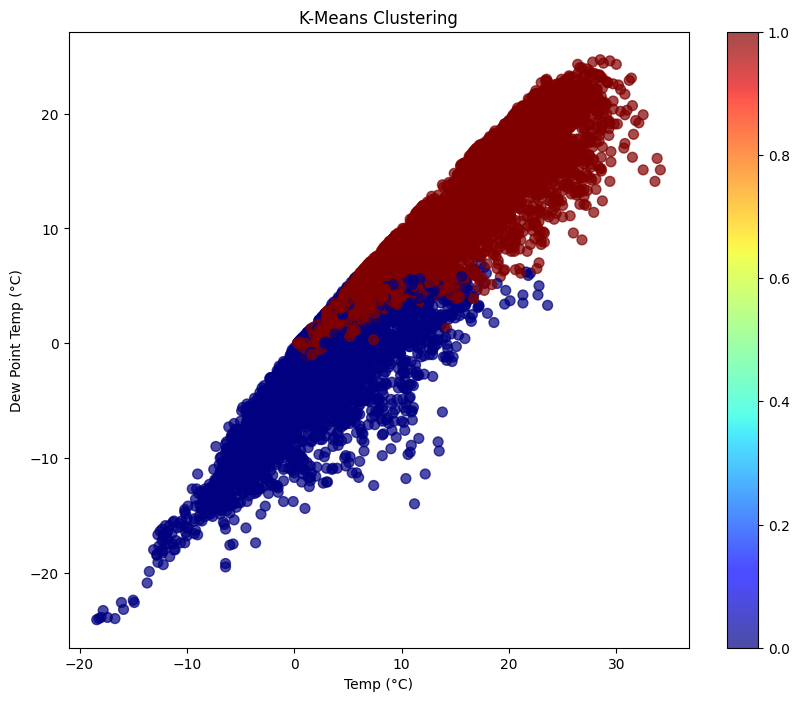

In [ ]:
# Create a scatter plot of v1 vs v2
# c=kmeans_labels colors the points according to the cluster labels
v1 = df_clean['Temp (°C)']
v2 = df_clean['Dew Point Temp (°C)']
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
scatter = ax.scatter(v1, v2, c=kmeans_labels[0],s=50,cmap='jet',alpha=0.7)
ax.set_title('K-Means Clustering')
ax.set_xlabel(v1.name)
ax.set_ylabel(v2.name)
plt.colorbar(scatter)
plt.show()


##Random Forest

###Model Training

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create a random forest regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

###Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2_score = model.score(X_test, y_test)
# Creating a DataFrame to tabulate the actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual Values': y_test.values,
    'Predicted Values': y_pred
})

# Displaying the results
results = f"""
Model Evaluation Results:
--------------------------
Mean Absolute Error (MAE): {mae}
Mean Squared Error (MSE): {mse}
R^2 Score: {r2_score}

Actual vs Predicted Values (First 10 samples):
"""

# Printing the evaluation results
print(results)

# Displaying the actual vs predicted values
print(comparison_df.head(10))


Model Evaluation Results:
--------------------------
Mean Absolute Error (MAE): 0.12558714608836613
Mean Squared Error (MSE): 0.05074076526438292
R^2 Score: 0.9994180858723073

Actual vs Predicted Values (First 10 samples):

   Actual Values  Predicted Values
0           15.6            15.434
1            1.9             1.745
2           16.5            16.658
3            3.9             3.819
4           -2.6            -2.467
5           17.0            16.686
6            1.0             1.013
7           21.8            21.792
8           24.1            24.225
9            1.0             1.125


###Feature Importance

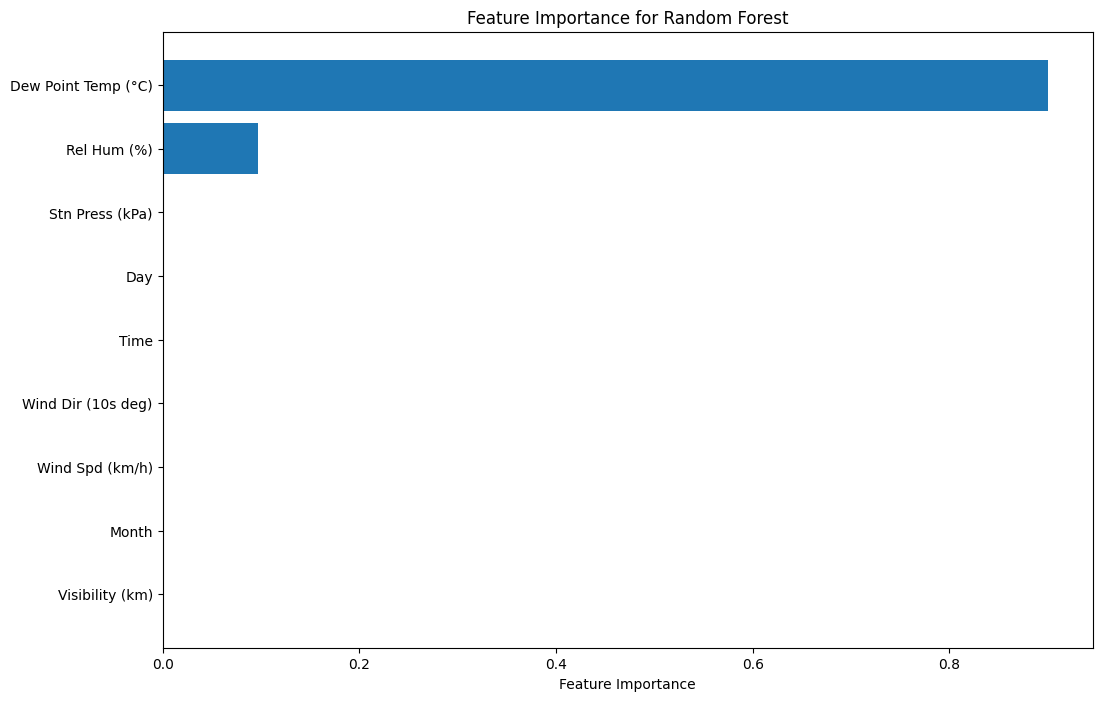

In [ ]:
# Feature Importance
importance = model.feature_importances_

# Creating a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

# Sorting the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Random Forest')
plt.gca().invert_yaxis()
plt.show()